# Comparision of different PRNGs (Model 2)

The Python code in this notebook will load the simulation results stored in the `statistics` folder and will generate the tables for model 2 (when changing $\rho$) - not shown in the report.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use('seaborn-v0_8')

## Load and process data

In [2]:
df = pd.read_csv("statistics/results2MG1-variatingRho.txt", header=None, names=["rng_mode", "ES", "EW", "EV", "ENQ", "EN", "time"], sep="\t")

In [3]:
# generators=df["rng_mode"].drop_duplicates().tolist()

# Sort the generators in the same order as in setup.prng_modes
import libs.setup as setup
generators= setup.prng_modes

## Helfer functions

In [4]:
def calc_EW(ES):
    """Calculate E[W] für M/G/1 by Pollaczek-Khintchine

    Args:
        ES (float): E[S]
    """
    EI = 100  # Fixed in model file
    StdS = 45  # Fixed in model file
    rho = ES / EI
    lmbda = 1 / EI
    # E[W]=(rho^2+lambda^2*Var[S])/(2*lambda(1-rho))
    return (rho**2 + lmbda**2 * StdS**2) / (2 * lmbda * (1 - rho))


def color_from_name(name):
    if name in ['SecureRandom', 'ISAAC']:
        return 'blue'
    if name in ['Drand48', 'Drand48Mix']:
        return 'red'
    return 'black'

## Generate diagrams

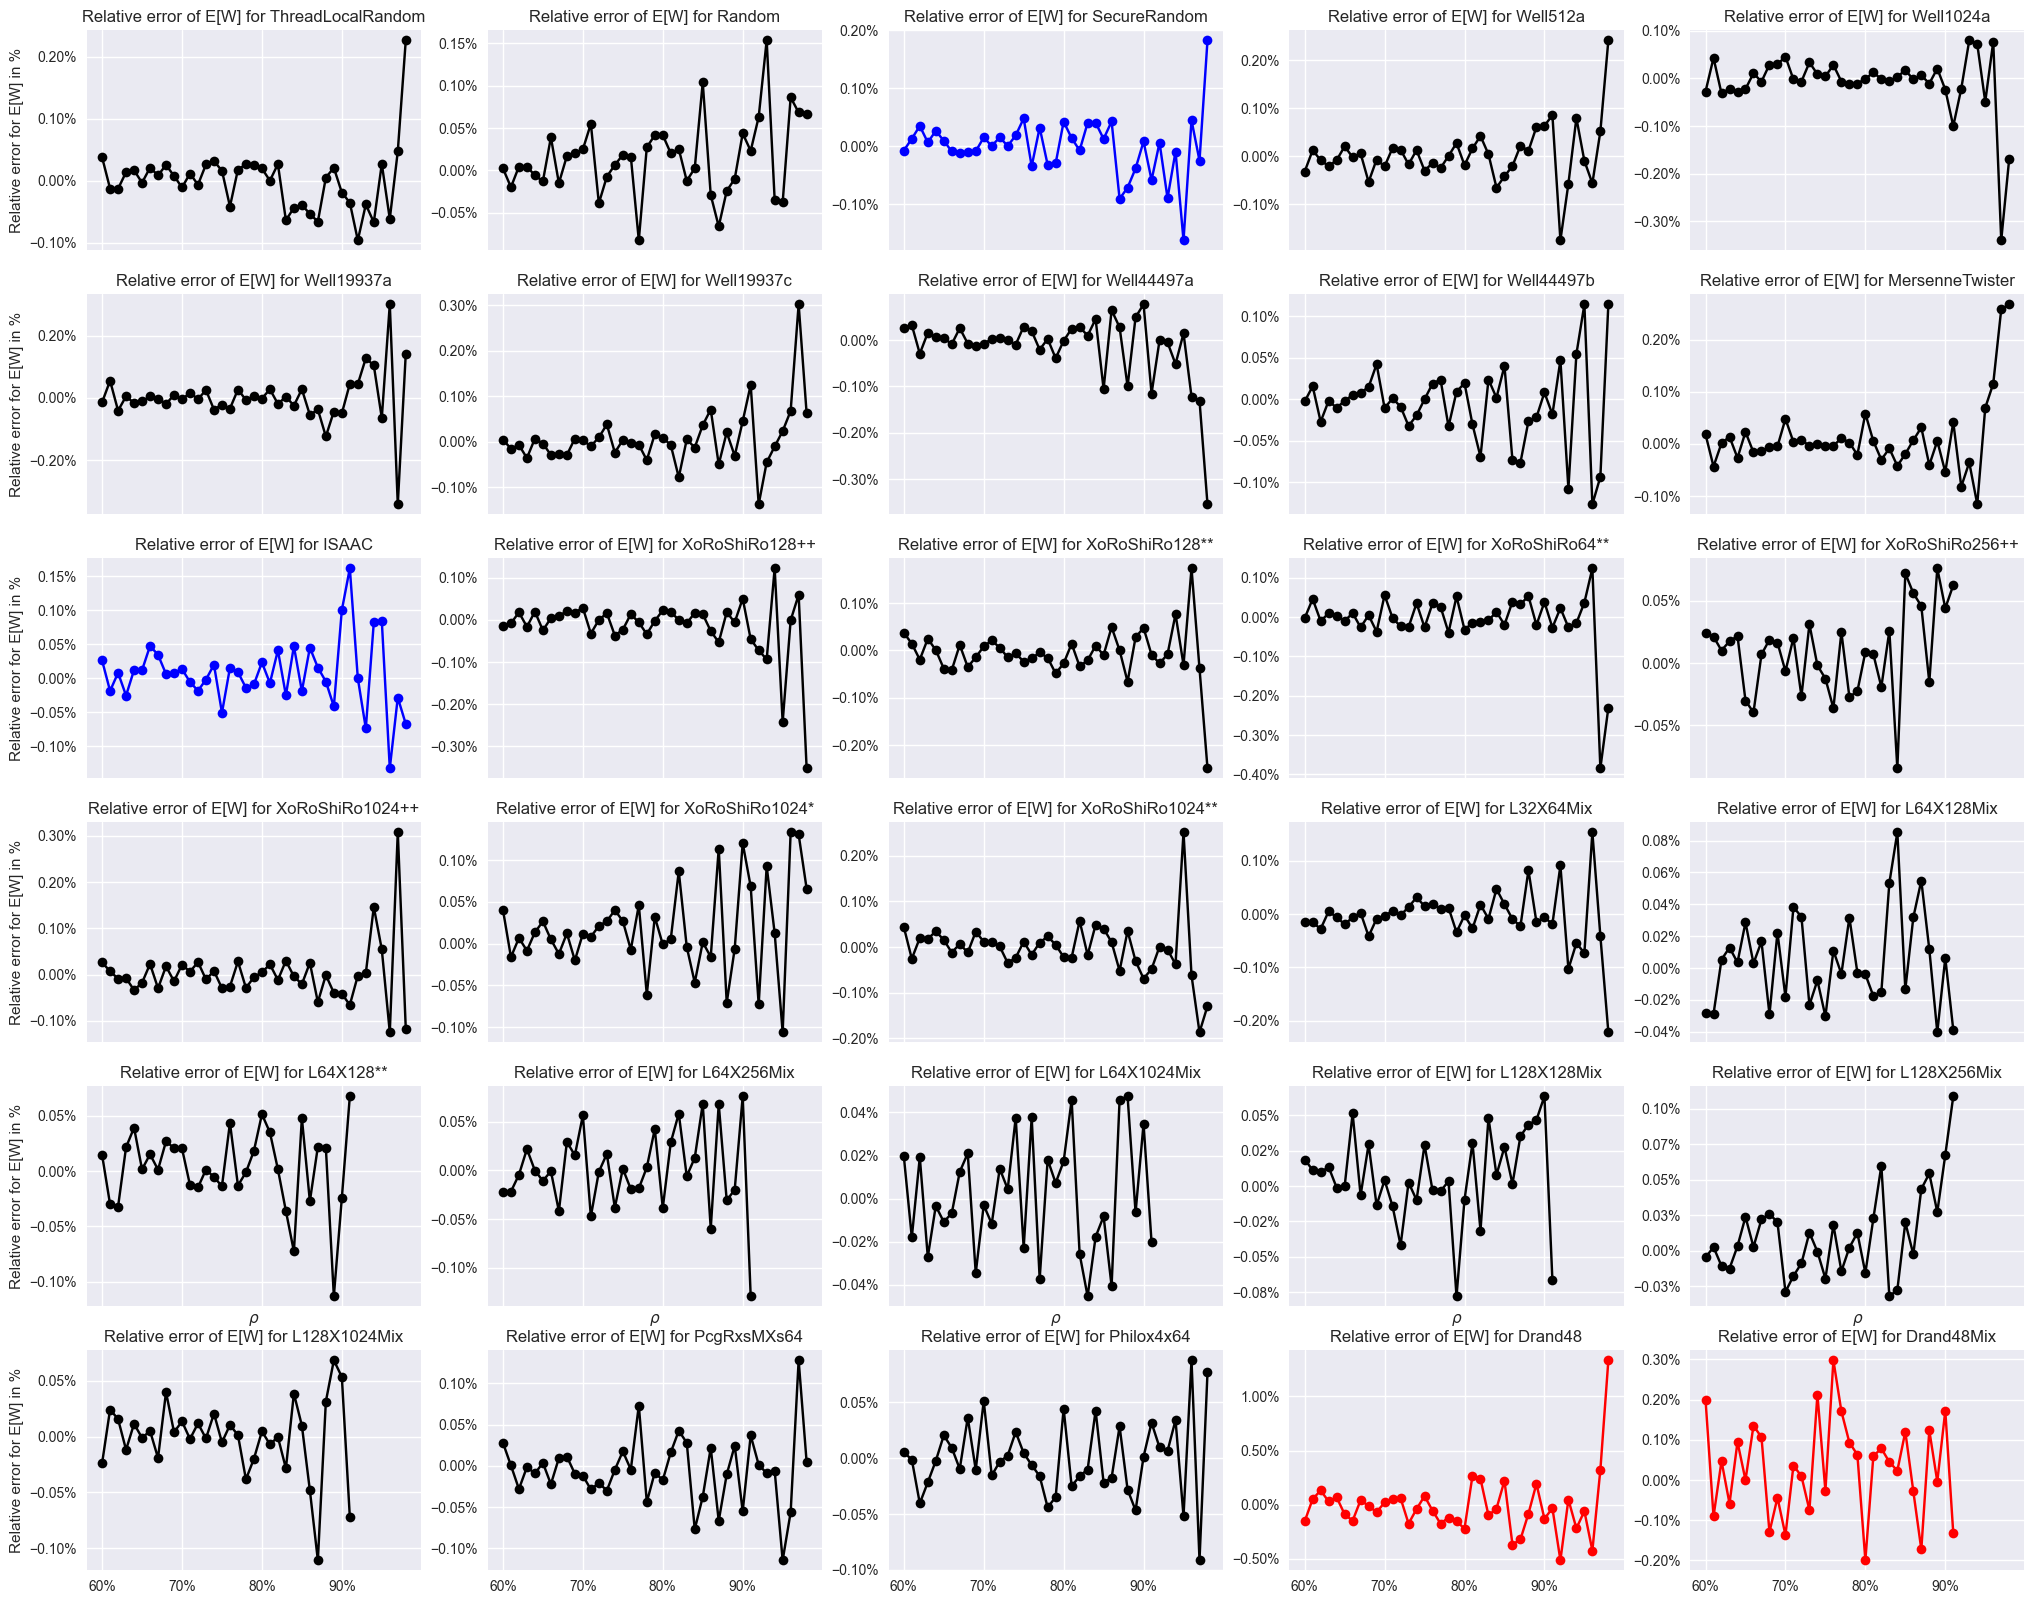

In [ ]:
def plot_rnd_mode(mode, ax, color):
    ES_vec = df[df["rng_mode"] == mode]["ES"].to_numpy()
    EW_sim = df[df["rng_mode"] == mode]["EW"].to_numpy()
    EW_exact = [calc_EW(ES) for ES in ES_vec]
    EW_rel_error = (EW_sim - EW_exact) / EW_exact
    ax.plot(ES_vec, EW_rel_error * 100, label="Relative error of E[W]", marker="o", color=color)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
    ax.set_title(f"Relative error of E[W] for {mode}")


fig, ax = plt.subplots(6, 5, figsize=(25, 20), sharex='col')

for i, mode in enumerate(generators):
    ax_val=ax[i // 5][i % 5]
    plot_rnd_mode(mode, ax_val, color_from_name(mode))
    if i // 5 == 4:
        ax_val.set_xlabel("$\\rho$")
    if i % 5 == 0:
        ax_val.set_ylabel("Relative error for E[W] in %")

# fig.savefig("plot2rho.png", format="png", bbox_inches='tight', pad_inches=0)

## Max relative error per generator

In [6]:
max_error=[]
for i, mode in enumerate(generators):
    ES_vec = df[df["rng_mode"] == mode]["ES"].to_numpy()
    EW_sim = df[df["rng_mode"] == mode]["EW"].to_numpy()
    EW_exact = [calc_EW(ES) for ES in ES_vec]
    max_EW_rel_error = np.abs((EW_sim - EW_exact) / EW_exact)
    max_error.append(np.max(max_EW_rel_error)*100)

max_error_df = pd.DataFrame({"max_rel_error": max_error}, index=generators)

s = max_error_df.style.format("{:.3f}%").set_caption("Max Relative Error (in \\%)")
print(s.to_html())

<style type="text/css">
</style>
<table id="T_4cc5f">
  <caption>Max Relative Error (in \%)</caption>
  <thead>
    <tr>
      <th class="blank level0" >&nbsp;</th>
      <th id="T_4cc5f_level0_col0" class="col_heading level0 col0" >max_rel_error</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th id="T_4cc5f_level0_row0" class="row_heading level0 row0" >ThreadLocalRandom</th>
      <td id="T_4cc5f_row0_col0" class="data row0 col0" >0.226%</td>
    </tr>
    <tr>
      <th id="T_4cc5f_level0_row1" class="row_heading level0 row1" >Random</th>
      <td id="T_4cc5f_row1_col0" class="data row1 col0" >0.153%</td>
    </tr>
    <tr>
      <th id="T_4cc5f_level0_row2" class="row_heading level0 row2" >SecureRandom</th>
      <td id="T_4cc5f_row2_col0" class="data row2 col0" >0.183%</td>
    </tr>
    <tr>
      <th id="T_4cc5f_level0_row3" class="row_heading level0 row3" >Well512a</th>
      <td id="T_4cc5f_row3_col0" class="data row3 col0" >0.242%</td>
    </tr>
    <tr>
      <th id="T_4

In [7]:
s = max_error_df.style.format("{:.3f}%").set_caption("Max Relative Error (in \\%)")
print(s.to_latex())

\begin{table}
\caption{Max Relative Error (in \%)}
\begin{tabular}{lr}
 & max_rel_error \\
ThreadLocalRandom & 0.226% \\
Random & 0.153% \\
SecureRandom & 0.183% \\
Well512a & 0.242% \\
Well1024a & 0.340% \\
Well19937a & 0.343% \\
Well19937c & 0.302% \\
Well44497a & 0.354% \\
Well44497b & 0.126% \\
MersenneTwister & 0.268% \\
ISAAC & 0.161% \\
XoRoShiRo128++ & 0.352% \\
XoRoShiRo128** & 0.249% \\
XoRoShiRo64** & 0.384% \\
XoRoShiRo256++ & 0.084% \\
XoRoShiRo1024++ & 0.308% \\
XoRoShiRo1024* & 0.133% \\
XoRoShiRo1024** & 0.251% \\
L32X64Mix & 0.222% \\
L64X128Mix & 0.085% \\
L64X128** & 0.113% \\
L64X256Mix & 0.130% \\
L64X1024Mix & 0.048% \\
L128X128Mix & 0.078% \\
L128X256Mix & 0.109% \\
L128X1024Mix & 0.111% \\
PcgRxsMXs64 & 0.128% \\
Philox4x64 & 0.091% \\
Drand48 & 1.335% \\
Drand48Mix & 0.298% \\
\end{tabular}
\end{table}



In [8]:
max_error_df

,max_rel_error
ThreadLocalRandom,0.226473
Random,0.153484
SecureRandom,0.182931
Well512a,0.242103
Well1024a,0.339815
Well19937a,0.342695
Well19937c,0.301729
Well44497a,0.354055
Well44497b,0.126298
MersenneTwister,0.267794
